# Assignment 8: Fraud Detection with Boosting

This notebook uses a real credit card fraud dataset to study boosting and additive models on an imbalanced binary classification problem. The main target is to implement AdaBoost with decision stumps, track how the model changes over boosting rounds, and compare it with simpler baseline classifiers.

The first section focuses on cleaning and preprocessing the real dataset so the later modeling steps use a consistent train/test split.

#### Study note: What this project is about

This project is about fraud detection using boosting. The main idea is that fraud is rare, so a normal accuracy score can be misleading. We are trying to show how AdaBoost learns from difficult examples by changing sample weights over many rounds.

In simple words: we are not only asking "does the model get many rows correct?" We are asking whether it can actually find the rare fraud cases.

## 1. Setup

We import the core scientific Python libraries and define constants used throughout the notebook. A fixed random seed makes the train/test split and later experiments reproducible.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

RANDOM_STATE = 42
DATA_PATH = Path("creditcard.csv")

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

#### Study note: Why this setup matters

This cell imports the basic tools we use in the notebook. `pandas` handles the dataset tables, `numpy` handles numerical calculations, and `Path` makes the file path easier to manage.

The random seed is important because it makes our train/test splits and synthetic dataset reproducible. If the teacher reruns the notebook, the results should stay the same.

## 2. Load the Real Fraud Dataset

The dataset contains anonymized credit card transactions. The variables `V1` through `V28` are transformed numerical features, while `Time` and `Amount` remain in their original units. The target variable is `Class`, where `1` indicates fraud and `0` indicates a normal transaction.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
display(df.head())

Dataset shape: 284,807 rows x 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


#### Study note: Loading the data

This cell reads the real credit card fraud dataset from `creditcard.csv`. The dataset has 284,807 transactions and 31 columns.

The target column is `Class`: `0` means a normal transaction and `1` means fraud. This is the real-world dataset required for the assignment.

## 3. Initial Data Quality Checks

Before modeling, we check the basic structure of the file: missing values, duplicated rows, data types, and the class distribution. This is especially important for fraud detection because the positive class is usually very rare.

In [3]:
quality_summary = pd.DataFrame(
    {
        "value": [
            df.shape[0],
            df.shape[1],
            df.isna().sum().sum(),
            df.duplicated().sum(),
            df["Class"].sum(),
            df["Class"].mean(),
        ]
    },
    index=[
        "rows",
        "columns",
        "missing_values_total",
        "duplicate_rows",
        "fraud_count",
        "fraud_rate",
    ],
)

class_counts = df["Class"].value_counts().rename_axis("Class").to_frame("count")
class_counts["percentage"] = df["Class"].value_counts(normalize=True).mul(100)

display(quality_summary)
display(class_counts)
display(df.dtypes.to_frame("dtype").T)

,value
rows,284807.0000
columns,31.0000
missing_values_total,0.0000
duplicate_rows,1081.0000
fraud_count,492.0000
fraud_rate,0.0017


,count,percentage
Class,,
0,284315,99.8273
1,492,0.1727


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


#### Study note: First data check

This cell checks the basic quality of the dataset: number of rows, missing values, duplicate rows, data types, and class balance.

The most important result is the class imbalance. There are 492 fraud transactions out of 284,807 total transactions, which is only about 0.173%.

In simple words: fraud is extremely rare here, so a model can look accurate even if it almost never catches fraud.

## 4. Clean Exact Duplicate Rows

The raw file contains exact duplicate records. For this assignment, we remove exact duplicates so that repeated identical transactions do not appear in both the train and test sets. After cleaning, we re-check the class distribution to make sure the imbalance remains visible.

In [4]:
df_clean = df.drop_duplicates().copy()

duplicate_cleaning_summary = pd.DataFrame(
    {
        "rows": [len(df), len(df_clean)],
        "fraud_count": [df["Class"].sum(), df_clean["Class"].sum()],
        "fraud_rate": [df["Class"].mean(), df_clean["Class"].mean()],
    },
    index=["before_duplicate_removal", "after_duplicate_removal"],
)

print(f"Removed {len(df) - len(df_clean):,} exact duplicate rows.")
display(duplicate_cleaning_summary)

Removed 1,081 exact duplicate rows.


,rows,fraud_count,fraud_rate
before_duplicate_removal,284807,492,0.0017
after_duplicate_removal,283726,473,0.0017


#### Study note: Removing exact duplicates

This cell removes rows that are exact copies of another row. We removed 1,081 duplicate rows. After cleaning, the dataset has 283,726 rows and 473 fraud cases.

This helps avoid a situation where the same transaction appears in both training and testing, which could make the model look better than it really is.

## 5. Prepare Features, Target, and Train/Test Split

The target is separated from the input features. We use a stratified train/test split so that the rare fraud class appears in both sets with approximately the same proportion as the cleaned dataset.

In [5]:
assert df_clean.isna().sum().sum() == 0, "Unexpected missing values after cleaning."
assert set(df_clean["Class"].unique()) == {0, 1}, "Target column should be binary."

def stratified_train_test_split(X, y, test_size=0.25, random_state=42):
    """Create a reproducible stratified train/test split using pandas and numpy."""
    rng = np.random.default_rng(random_state)
    train_indices = []
    test_indices = []

    for class_label in sorted(y.unique()):
        class_indices = y[y == class_label].index.to_numpy().copy()
        rng.shuffle(class_indices)

        n_test = int(np.ceil(len(class_indices) * test_size))
        test_indices.extend(class_indices[:n_test])
        train_indices.extend(class_indices[n_test:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)
    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return X.loc[train_indices], X.loc[test_indices], y.loc[train_indices], y.loc[test_indices]


feature_cols = [col for col in df_clean.columns if col != "Class"]
X = df_clean[feature_cols]
y = df_clean["Class"]

X_train, X_test, y_train, y_test = stratified_train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "fraud_count": [y_train.sum(), y_test.sum()],
        "fraud_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)

display(split_summary)

,rows,fraud_count,fraud_rate
train,212793,354,0.0017
test,70933,119,0.0017


#### Study note: Train/test split

This cell separates the features from the target and creates a train/test split. We use a stratified split, which means the rare fraud class keeps almost the same percentage in both sets.

The training set has 212,793 rows with 354 frauds. The test set has 70,933 rows with 119 frauds.

In simple words: we train the model on one part of the data, then test it on data it has not seen before.

## 6. Scale `Time` and `Amount` Without Data Leakage

`V1` through `V28` are already transformed numeric variables. `Time` and `Amount` are on different scales, so we standardize those two columns. The mean and standard deviation are computed only from the training data and then applied to the test data, which avoids leaking information from the test set into preprocessing.

In [6]:
columns_to_scale = ["Time", "Amount"]
scale_means = X_train[columns_to_scale].mean()
scale_stds = X_train[columns_to_scale].std(ddof=0)

X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

X_train_processed[columns_to_scale] = (X_train[columns_to_scale] - scale_means) / scale_stds
X_test_processed[columns_to_scale] = (X_test[columns_to_scale] - scale_means) / scale_stds

display(X_train_processed[columns_to_scale].describe().loc[["mean", "std", "min", "max"]])
display(X_test_processed[columns_to_scale].describe().loc[["mean", "std", "min", "max"]])

,Time,Amount
mean,-0.0000,-0.0000
std,1.0000,1.0000
min,-1.9971,-0.3537
max,1.6425,102.4009


,Time,Amount
mean,-0.0001,0.0008
std,1.0004,1.0060
min,-1.9971,-0.3537
max,1.6424,78.2647


#### Study note: Scaling without leakage

This cell standardizes `Time` and `Amount`, because they are on different scales from the anonymized `V1` to `V28` features. The mean and standard deviation are computed using only the training data.

This matters because using information from the test set during preprocessing would be data leakage. Data leakage makes results look more impressive than they should.

## Preprocessing Outputs

The cleaned and preprocessed objects created in this section are:

- `df_clean`: dataset after exact duplicate removal.
- `X_train_processed`, `X_test_processed`: feature matrices ready for modeling.
- `y_train`, `y_test`: target vectors for evaluation.
- `feature_cols`: ordered list of model input columns.

Next, we explore the cleaned data and build the synthetic dataset required for the assignment.

## 7. Exploratory Analysis of the Cleaned Dataset

This short exploratory analysis focuses on the variables that are still interpretable: the class label, transaction amount, and transaction time. The anonymized `V` columns are useful for prediction, but they do not have business-readable meanings.

In [7]:
clean_class_summary = df_clean["Class"].value_counts().rename_axis("Class").to_frame("count")
clean_class_summary["percentage"] = df_clean["Class"].value_counts(normalize=True).mul(100)

amount_summary_by_class = df_clean.groupby("Class")["Amount"].describe(
    percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]
)

time_summary_by_class = (
    df_clean.assign(Time_hours=df_clean["Time"] / 3600)
    .groupby("Class")["Time_hours"]
    .describe(percentiles=[0.25, 0.50, 0.75])
)

display(clean_class_summary)
display(amount_summary_by_class)
display(time_summary_by_class)

,count,percentage
Class,,
0,283253,99.8333
1,473,0.1667


,count,mean,std,min,1%,25%,50%,75%,99%,max
Class,,,,,,,,,,
0,283253.0000,88.4136,250.3790,0.0000,0.1200,5.6700,22.0000,77.4600,1018.0576,25691.1600
1,473.0000,123.8719,260.2110,0.0000,0.0000,1.0000,9.8200,105.8900,1364.1368,2125.8700


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0000,26.3431,13.1877,0.0000,15.0647,23.5308,38.6967,47.9978
1,473.0000,22.3474,13.5100,0.1128,11.4453,20.3911,35.8597,47.3189


#### Study note: Understanding the cleaned data

This cell summarizes the cleaned dataset by class. It compares transaction amounts and time values for normal versus fraud transactions.

One interesting result is that the median fraud amount is lower than the median normal amount, but the mean fraud amount is higher. So fraud is not simply "large transactions only." 

The fraud class is extremely rare, so the class-count plot uses a log-scaled y-axis. The amount plot clips very large transactions at 1,000 for visualization only; the original values remain unchanged in the modeling data.

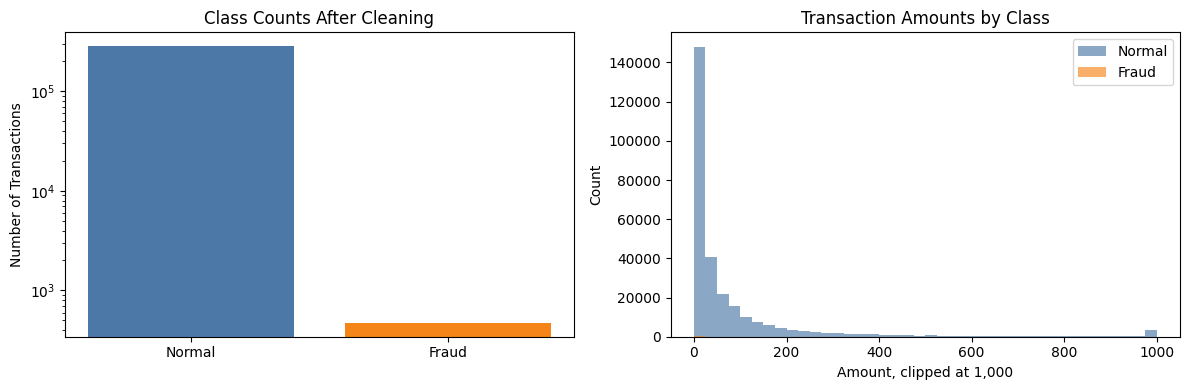

In [8]:
try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False
    print("Matplotlib is not installed in this Python environment, so plot cells will be skipped.")

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(["Normal", "Fraud"], clean_class_summary.loc[[0, 1], "count"], color=["#4C78A8", "#F58518"])
    axes[0].set_title("Class Counts After Cleaning")
    axes[0].set_ylabel("Number of Transactions")
    axes[0].set_yscale("log")

    normal_amounts = df_clean.loc[df_clean["Class"] == 0, "Amount"].clip(upper=1000)
    fraud_amounts = df_clean.loc[df_clean["Class"] == 1, "Amount"].clip(upper=1000)
    axes[1].hist(normal_amounts, bins=40, alpha=0.65, label="Normal", color="#4C78A8")
    axes[1].hist(fraud_amounts, bins=40, alpha=0.65, label="Fraud", color="#F58518")
    axes[1].set_title("Transaction Amounts by Class")
    axes[1].set_xlabel("Amount, clipped at 1,000")
    axes[1].set_ylabel("Count")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

#### Study note: Why these plots are useful

This cell makes quick visualizations of class imbalance and transaction amounts. The class-count plot uses a log scale because fraud is so rare that a normal scale would make the fraud bar almost invisible.

The amount plot is only for visualization. We clip very large amounts in the plot so the shape is easier to see, but the modeling data is not changed.

## 8. Create a Synthetic Imbalanced Classification Dataset

The assignment also requires a synthetic classification dataset. We create a two-feature binary dataset with roughly 95% normal observations and 5% fraud observations. The classes overlap, and a small fraction of points are feature outliers, so the problem is intentionally not perfectly separable.

In [9]:
def make_synthetic_fraud_data(n_samples=2500, fraud_rate=0.05, random_state=42):
    """Generate a small imbalanced binary dataset for visualizing boosting behavior."""
    rng = np.random.default_rng(random_state)
    n_fraud = int(round(n_samples * fraud_rate))
    n_normal = n_samples - n_fraud

    normal_features = rng.multivariate_normal(
        mean=[0.0, 0.0],
        cov=[[1.25, 0.55], [0.55, 1.00]],
        size=n_normal,
    )
    fraud_features = rng.multivariate_normal(
        mean=[1.55, 1.25],
        cov=[[1.00, -0.35], [-0.35, 1.10]],
        size=n_fraud,
    )

    X_synthetic = np.vstack([normal_features, fraud_features])
    y_synthetic = np.concatenate([np.zeros(n_normal, dtype=int), np.ones(n_fraud, dtype=int)])

    n_outliers = max(1, int(0.03 * n_samples))
    outlier_indices = rng.choice(n_samples, size=n_outliers, replace=False)
    X_synthetic[outlier_indices] += rng.normal(loc=0.0, scale=2.75, size=(n_outliers, 2))

    shuffled_indices = rng.permutation(n_samples)
    synthetic_df = pd.DataFrame(
        X_synthetic[shuffled_indices],
        columns=["feature_1", "feature_2"],
    )
    synthetic_df["Class"] = y_synthetic[shuffled_indices]

    return synthetic_df


synthetic_df = make_synthetic_fraud_data(random_state=RANDOM_STATE)

synthetic_class_summary = synthetic_df["Class"].value_counts().rename_axis("Class").to_frame("count")
synthetic_class_summary["percentage"] = synthetic_df["Class"].value_counts(normalize=True).mul(100)

display(synthetic_df.head())
display(synthetic_class_summary)
display(synthetic_df.groupby("Class")[["feature_1", "feature_2"]].describe())

,feature_1,feature_2,Class
0,-0.5652,0.9685,0
1,0.0386,0.3458,0
2,0.9051,0.2681,0
3,1.0017,1.5374,0
4,-0.9378,-0.1798,0


,count,percentage
Class,,
0,2375,95.0000
1,125,5.0000


feature_1                                                    feature_2  \
          count   mean    std     min     25%    50%    75%    max     count   
Class                                                                          
0     2375.0000 0.0257 1.2358 -6.4592 -0.7325 0.0170 0.8241 7.4825 2375.0000   
1      125.0000 1.4358 0.9949 -1.1421  0.6972 1.5385 2.1336 4.0767  125.0000   

                                                          
        mean    std     min     25%    50%    75%    max  
Class                                                     
0     0.0145 1.0798 -5.2565 -0.6413 0.0070 0.7057 5.0763  
1     1.1426 1.1023 -2.3350  0.4608 1.0987 1.8535 3.8134

#### Study note: Synthetic dataset

The assignment asks for one real dataset and one synthetic dataset. This cell creates the synthetic one. It has two numeric features, about 95% normal cases and 5% fraud cases, plus overlap and outliers.

The point of the synthetic dataset is that it is easier to visualize and easier to use for explaining how AdaBoost behaves.

In [10]:
X_syn = synthetic_df[["feature_1", "feature_2"]]
y_syn = synthetic_df["Class"]

X_syn_train, X_syn_test, y_syn_train, y_syn_test = stratified_train_test_split(
    X_syn,
    y_syn,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

synthetic_means = X_syn_train.mean()
synthetic_stds = X_syn_train.std(ddof=0)
X_syn_train_processed = (X_syn_train - synthetic_means) / synthetic_stds
X_syn_test_processed = (X_syn_test - synthetic_means) / synthetic_stds

synthetic_split_summary = pd.DataFrame(
    {
        "rows": [len(X_syn_train_processed), len(X_syn_test_processed)],
        "fraud_count": [y_syn_train.sum(), y_syn_test.sum()],
        "fraud_rate": [y_syn_train.mean(), y_syn_test.mean()],
    },
    index=["synthetic_train", "synthetic_test"],
)

display(synthetic_split_summary)

,rows,fraud_count,fraud_rate
synthetic_train,1874,93,0.0496
synthetic_test,626,32,0.0511


#### Study note: Preparing synthetic train/test data

This cell splits and scales the synthetic dataset the same way we handled the real dataset.

This gives us a smaller controlled experiment before we run AdaBoost on the real fraud data.

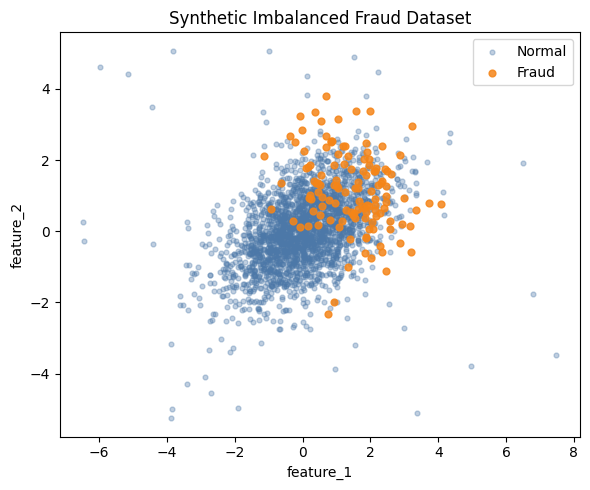

In [11]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(6, 5))

    normal_points = synthetic_df[synthetic_df["Class"] == 0]
    fraud_points = synthetic_df[synthetic_df["Class"] == 1]
    ax.scatter(normal_points["feature_1"], normal_points["feature_2"], s=12, alpha=0.35, label="Normal", color="#4C78A8")
    ax.scatter(fraud_points["feature_1"], fraud_points["feature_2"], s=24, alpha=0.85, label="Fraud", color="#F58518")

    ax.set_title("Synthetic Imbalanced Fraud Dataset")
    ax.set_xlabel("feature_1")
    ax.set_ylabel("feature_2")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Synthetic data was created. Install matplotlib to display the scatter plot.")

#### Study note: Visualizing the synthetic data

This scatter plot shows the synthetic normal and fraud points. The classes overlap on purpose, so the task is not too easy.

In simple words: this dataset is artificial, but it helps us see why fraud detection is difficult when the fraud class is rare and mixed with normal cases.

## Batch 2 Outputs

This section added exploratory summaries for the cleaned real dataset and created the synthetic dataset required by the assignment.

The main objects created here are:

- `synthetic_df`: synthetic imbalanced dataset with two numeric features and a binary target.
- `X_syn_train_processed`, `X_syn_test_processed`: scaled synthetic feature matrices.
- `y_syn_train`, `y_syn_test`: synthetic target vectors.

Next, we will implement AdaBoost with decision stumps from scratch.

## 9. AdaBoost with Decision Stumps from Scratch

AdaBoost builds an additive classifier by repeatedly fitting weak learners to weighted data. After each round, observations that were misclassified receive larger weights, so the next weak learner focuses more strongly on difficult cases.

For binary AdaBoost, labels are encoded as `-1` and `+1`. Each decision stump makes a one-feature threshold rule, and the final model combines all stump predictions using their learned contributions, called alpha values.

In [12]:
def encode_binary_labels(y):
    """Convert labels from {0, 1} to {-1, +1}."""
    y_array = np.asarray(y).astype(int)
    unique_labels = set(np.unique(y_array))
    if not unique_labels.issubset({0, 1}):
        raise ValueError("AdaBoost implementation expects binary labels coded as 0 and 1.")
    return np.where(y_array == 1, 1, -1)


def get_feature_matrix(X):
    """Return a numeric numpy matrix and feature names from a DataFrame or array."""
    if isinstance(X, pd.DataFrame):
        return X.to_numpy(dtype=float), list(X.columns)

    X_array = np.asarray(X, dtype=float)
    if X_array.ndim == 1:
        X_array = X_array.reshape(-1, 1)
    feature_names = [f"feature_{idx}" for idx in range(X_array.shape[1])]
    return X_array, feature_names


def candidate_thresholds(values, max_thresholds=80):
    """Choose candidate thresholds for a numeric feature."""
    unique_values = np.unique(values)
    if len(unique_values) <= 1:
        return unique_values

    if max_thresholds is None or len(unique_values) <= max_thresholds + 1:
        return (unique_values[:-1] + unique_values[1:]) / 2

    quantiles = np.linspace(0, 1, max_thresholds + 2)[1:-1]
    return np.unique(np.quantile(values, quantiles))


def predict_decision_stump(X, stump):
    """Predict {-1, +1} labels using one fitted decision stump."""
    X_array, _ = get_feature_matrix(X)
    column = X_array[:, stump["feature_index"]]
    base_prediction = np.where(column <= stump["threshold"], -1, 1)
    return stump["polarity"] * base_prediction

#### Study note: Helper functions for AdaBoost

This cell prepares helper functions for our from-scratch AdaBoost model. AdaBoost works more naturally with labels coded as `-1` and `+1`, so we convert `0` and `1` into that format.

The decision stump prediction function applies a simple one-feature threshold rule. A stump is like a tiny decision tree with only one split.

### Decision Stump Learner

The weak learner searches over one-feature threshold rules and chooses the rule with the lowest weighted classification error. The `polarity` parameter allows the rule direction to flip, so the stump can predict fraud on either side of a threshold.

In [13]:
def fit_decision_stump(X, y_signed, sample_weights=None, max_thresholds=80):
    """Fit the best weighted decision stump for signed labels."""
    X_array, feature_names = get_feature_matrix(X)
    y_signed = np.asarray(y_signed).astype(int)
    n_samples, n_features = X_array.shape

    if sample_weights is None:
        sample_weights = np.full(n_samples, 1 / n_samples)
    else:
        sample_weights = np.asarray(sample_weights, dtype=float)
        sample_weights = sample_weights / sample_weights.sum()

    best_stump = {
        "feature_index": None,
        "feature_name": None,
        "threshold": None,
        "polarity": 1,
        "error": np.inf,
    }

    for feature_index in range(n_features):
        feature_values = X_array[:, feature_index]
        thresholds = candidate_thresholds(feature_values, max_thresholds=max_thresholds)

        for threshold in thresholds:
            base_prediction = np.where(feature_values <= threshold, -1, 1)
            error = sample_weights[base_prediction != y_signed].sum()

            if error <= 0.5:
                polarity = 1
                weighted_error = error
            else:
                polarity = -1
                weighted_error = 1 - error

            if weighted_error < best_stump["error"]:
                best_stump = {
                    "feature_index": feature_index,
                    "feature_name": feature_names[feature_index],
                    "threshold": float(threshold),
                    "polarity": polarity,
                    "error": float(weighted_error),
                }

    if best_stump["feature_index"] is None:
        raise ValueError("No valid decision stump could be fitted.")

    return best_stump

#### Study note: Decision stump learner

This cell builds the weak learner used by AdaBoost. It searches through features and thresholds, then chooses the stump with the lowest weighted error.

The important part is "weighted error." AdaBoost changes sample weights every round, so later stumps focus more on examples that previous stumps struggled with.

### AdaBoost Training Loop

At each boosting round, the algorithm fits a stump, computes its alpha contribution, updates sample weights, and records diagnostics. The diagnostics are part of the assignment requirements because they show how boosting concentrates attention on hard observations.

In [14]:
def fit_adaboost_stumps(X, y, n_estimators=50, learning_rate=1.0, max_thresholds=80, initial_weighting="uniform"):
    """Fit AdaBoost using decision stumps and return the model plus training history."""
    X_array, feature_names = get_feature_matrix(X)
    y_signed = encode_binary_labels(y)
    n_samples = len(y_signed)

    if initial_weighting == "uniform":
        sample_weights = np.full(n_samples, 1 / n_samples)
    elif initial_weighting == "balanced":
        sample_weights = np.zeros(n_samples)
        for class_label in [-1, 1]:
            class_mask = y_signed == class_label
            sample_weights[class_mask] = 0.5 / class_mask.sum()
    else:
        raise ValueError("initial_weighting must be either 'uniform' or 'balanced'.")
    stumps = []
    alphas = []
    training_scores = np.zeros(n_samples)
    history_rows = []
    eps = 1e-12

    for iteration in range(1, n_estimators + 1):
        stump = fit_decision_stump(
            X_array,
            y_signed,
            sample_weights=sample_weights,
            max_thresholds=max_thresholds,
        )
        stump_predictions = predict_decision_stump(X_array, stump)
        stump_error = np.clip(stump["error"], eps, 1 - eps)

        if stump_error >= 0.5 - eps:
            print(f"Stopping at round {iteration}: weak learner error is not better than chance.")
            break

        alpha = learning_rate * 0.5 * np.log((1 - stump_error) / stump_error)
        sample_weights *= np.exp(-alpha * y_signed * stump_predictions)
        sample_weights /= sample_weights.sum()

        stumps.append(stump)
        alphas.append(float(alpha))
        training_scores += alpha * stump_predictions
        training_predictions = np.where(training_scores >= 0, 1, -1)

        history_rows.append(
            {
                "iteration": iteration,
                "feature": stump["feature_name"],
                "threshold": stump["threshold"],
                "polarity": stump["polarity"],
                "stump_error": float(stump_error),
                "alpha": float(alpha),
                "training_error": float(np.mean(training_predictions != y_signed)),
                "max_sample_weight": float(sample_weights.max()),
                "effective_sample_size": float(1 / np.sum(sample_weights ** 2)),
                "positive_weight_share": float(sample_weights[y_signed == 1].sum()),
            }
        )

    return {
        "stumps": stumps,
        "alphas": np.array(alphas),
        "feature_names": feature_names,
        "history": pd.DataFrame(history_rows),
    }


def adaboost_decision_function(X, model):
    """Return the signed additive score from a fitted AdaBoost model."""
    X_array, _ = get_feature_matrix(X)
    scores = np.zeros(X_array.shape[0])

    for alpha, stump in zip(model["alphas"], model["stumps"]):
        scores += alpha * predict_decision_stump(X_array, stump)

    return scores


def predict_adaboost(X, model):
    """Predict labels in {0, 1} from a fitted AdaBoost model."""
    scores = adaboost_decision_function(X, model)
    return np.where(scores >= 0, 1, 0)

#### Study note: AdaBoost training loop

This is the main AdaBoost implementation from scratch. Each round fits a decision stump, calculates its alpha value, updates sample weights, and records what happened.

Alpha means how much that weak learner contributes to the final model. Better stumps get larger alpha values.

In simple words: AdaBoost builds a team of simple rules, and each rule gets a vote based on how reliable it is.

## 10. Smoke Test on the Synthetic Dataset

Before running the full experiments, we test the implementation on the smaller synthetic dataset. This confirms that the model can fit several boosting rounds and that the required tracking table is being created.

In [15]:
ada_syn_model = fit_adaboost_stumps(
    X_syn_train_processed,
    y_syn_train,
    n_estimators=20,
    learning_rate=1.0,
    max_thresholds=None,
)

ada_syn_history = ada_syn_model["history"]
display(ada_syn_history.head())
display(ada_syn_history.tail())

,iteration,feature,threshold,polarity,stump_error,alpha,training_error,max_sample_weight,effective_sample_size,positive_weight_share
0,1,feature_0,-5.2759,-1,0.0502,1.4705,0.0502,0.0053,357.1398,0.4947
1,2,feature_0,0.3349,1,0.2564,0.5323,0.0502,0.0104,329.6657,0.4481
2,3,feature_1,1.0460,1,0.3017,0.4196,0.0502,0.0172,222.3212,0.5272
3,4,feature_1,0.0349,1,0.3497,0.3101,0.0502,0.0132,293.4736,0.4446
4,5,feature_0,1.3838,1,0.3529,0.3032,0.0630,0.0187,199.4391,0.5177


,iteration,feature,threshold,polarity,stump_error,alpha,training_error,max_sample_weight,effective_sample_size,positive_weight_share
15,16,feature_0,0.2917,-1,0.4619,0.0762,0.0518,0.0187,244.3665,0.4907
16,17,feature_0,0.8589,1,0.4602,0.0799,0.0630,0.0203,228.5674,0.4947
17,18,feature_1,1.1508,-1,0.4644,0.0714,0.0534,0.0190,249.7191,0.4787
18,19,feature_1,1.7980,1,0.4524,0.0955,0.0518,0.0210,215.8140,0.5140
19,20,feature_0,-1.0023,1,0.4637,0.0727,0.0544,0.0195,242.1113,0.4792


#### Study note: AdaBoost smoke test

This cell runs the from-scratch AdaBoost model on the synthetic dataset first. This is a sanity check before using the larger real fraud dataset.

The history table shows each boosting round, the selected feature, the threshold, the stump error, the alpha value, and how sample weights changed.

In [16]:
syn_train_pred = predict_adaboost(X_syn_train_processed, ada_syn_model)
syn_test_pred = predict_adaboost(X_syn_test_processed, ada_syn_model)

synthetic_smoke_test = pd.DataFrame(
    {
        "error_rate": [
            np.mean(syn_train_pred != y_syn_train.to_numpy()),
            np.mean(syn_test_pred != y_syn_test.to_numpy()),
        ],
        "fraud_predictions": [syn_train_pred.sum(), syn_test_pred.sum()],
        "actual_frauds": [y_syn_train.sum(), y_syn_test.sum()],
    },
    index=["synthetic_train", "synthetic_test"],
)

display(synthetic_smoke_test)

,error_rate,fraud_predictions,actual_frauds
synthetic_train,0.0544,27,93
synthetic_test,0.0607,8,32


#### Study note: First synthetic result

This cell evaluates the first synthetic AdaBoost model. The early result looked accurate, but it did not catch many fraud cases.

That is not a failure of the code. It is the lesson of imbalanced data: high accuracy can hide poor fraud detection.

## Batch 3 Outputs

This section implemented AdaBoost with decision stumps from scratch. The implementation records the weak learner feature, threshold, polarity, alpha contribution, training error, maximum sample weight, effective sample size, and total sample-weight share assigned to the positive class.

Next, we will add reusable evaluation metrics and run the main experiments on both the synthetic and real fraud datasets.

## 11. Evaluation Metrics for Imbalanced Fraud Detection

For fraud detection, accuracy is not enough because a model can predict nearly every transaction as normal and still look accurate. We therefore compute precision, recall, F1 score, balanced accuracy, and average precision from the model scores.

In [ ]:
def average_precision_score_from_scratch(y_true, scores):
    """Compute average precision for binary labels without external libraries."""
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)
    total_positives = y_true.sum()

    if total_positives == 0:
        return np.nan

    order = np.argsort(-scores)
    sorted_true = y_true[order]
    cumulative_true = np.cumsum(sorted_true)
    precision_at_k = cumulative_true / (np.arange(len(sorted_true)) + 1)

    return float((precision_at_k * sorted_true).sum() / total_positives)


def classification_metrics(y_true, y_pred, scores=None):
    """Return core fraud-detection metrics for binary labels coded as 0 and 1."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    balanced_accuracy = 0.5 * (recall + specificity)

    metrics = {
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "accuracy": accuracy,
        "error_rate": 1 - accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "balanced_accuracy": balanced_accuracy,
        "actual_positive_rate": y_true.mean(),
        "predicted_positive_rate": y_pred.mean(),
    }

    if scores is not None:
        metrics["average_precision"] = average_precision_score_from_scratch(y_true, scores)

    return metrics


def metrics_table(rows):
    """Create a formatted DataFrame from named metric dictionaries."""
    return pd.DataFrame(rows).T

#### Study note: Better metrics for fraud

This cell defines the metrics we need for imbalanced classification: precision, recall, F1, balanced accuracy, and average precision.

Precision answers: when the model says fraud, how often is it right? Recall answers: out of all real frauds, how many did the model catch?

For this project, recall and precision are much more meaningful than accuracy alone.

## 12. Per-Iteration AdaBoost Evaluation

The assignment asks us to track training and test error over boosting iterations. The function below evaluates the partial additive model after each round, so we can see whether test performance improves, flattens, or worsens as more stumps are added.

In [ ]:
def adaboost_iteration_metrics(model, X_train_eval, y_train_eval, X_test_eval, y_test_eval):
    """Evaluate train/test metrics after each boosting round."""
    X_train_array, _ = get_feature_matrix(X_train_eval)
    X_test_array, _ = get_feature_matrix(X_test_eval)
    y_train_array = np.asarray(y_train_eval).astype(int)
    y_test_array = np.asarray(y_test_eval).astype(int)

    train_scores = np.zeros(len(y_train_array))
    test_scores = np.zeros(len(y_test_array))
    rows = []

    for iteration, (alpha, stump) in enumerate(zip(model["alphas"], model["stumps"]), start=1):
        train_scores += alpha * predict_decision_stump(X_train_array, stump)
        test_scores += alpha * predict_decision_stump(X_test_array, stump)

        train_pred = np.where(train_scores >= 0, 1, 0)
        test_pred = np.where(test_scores >= 0, 1, 0)
        train_metrics = classification_metrics(y_train_array, train_pred, train_scores)
        test_metrics = classification_metrics(y_test_array, test_pred, test_scores)

        rows.append(
            {
                "iteration": iteration,
                "train_error": train_metrics["error_rate"],
                "test_error": test_metrics["error_rate"],
                "train_precision": train_metrics["precision"],
                "test_precision": test_metrics["precision"],
                "train_recall": train_metrics["recall"],
                "test_recall": test_metrics["recall"],
                "train_f1": train_metrics["f1"],
                "test_f1": test_metrics["f1"],
                "train_average_precision": train_metrics["average_precision"],
                "test_average_precision": test_metrics["average_precision"],
            }
        )

    return pd.DataFrame(rows)


def summarize_final_model(name, model, X_train_eval, y_train_eval, X_test_eval, y_test_eval):
    """Summarize final train/test metrics for a fitted AdaBoost model."""
    train_scores = adaboost_decision_function(X_train_eval, model)
    test_scores = adaboost_decision_function(X_test_eval, model)
    train_pred = np.where(train_scores >= 0, 1, 0)
    test_pred = np.where(test_scores >= 0, 1, 0)

    return metrics_table(
        {
            f"{name}_train": classification_metrics(y_train_eval, train_pred, train_scores),
            f"{name}_test": classification_metrics(y_test_eval, test_pred, test_scores),
        }
    )

#### Study note: Tracking performance over boosting rounds

This cell evaluates the AdaBoost model after each boosting round. This directly matches the assignment requirement to track training error and test error over iterations.

This lets us see whether adding more weak learners improves the model, stops helping, or starts making test performance worse.

## 13. Synthetic Dataset: Uniform vs Class-Balanced AdaBoost

The earlier smoke test used uniform initial sample weights. Here we compare it to class-balanced initial weights, where the normal class starts with total weight 0.5 and the fraud class also starts with total weight 0.5. This does not change the AdaBoost update rule, but it changes what the first weak learners pay attention to.

In [ ]:
ada_syn_uniform_model = fit_adaboost_stumps(
    X_syn_train_processed,
    y_syn_train,
    n_estimators=25,
    learning_rate=1.0,
    max_thresholds=None,
    initial_weighting="uniform",
)

ada_syn_balanced_model = fit_adaboost_stumps(
    X_syn_train_processed,
    y_syn_train,
    n_estimators=25,
    learning_rate=1.0,
    max_thresholds=None,
    initial_weighting="balanced",
)

syn_uniform_summary = summarize_final_model(
    "synthetic_uniform",
    ada_syn_uniform_model,
    X_syn_train_processed,
    y_syn_train,
    X_syn_test_processed,
    y_syn_test,
)
syn_balanced_summary = summarize_final_model(
    "synthetic_balanced",
    ada_syn_balanced_model,
    X_syn_train_processed,
    y_syn_train,
    X_syn_test_processed,
    y_syn_test,
)

synthetic_model_comparison = pd.concat([syn_uniform_summary, syn_balanced_summary])
display(synthetic_model_comparison[["accuracy", "precision", "recall", "f1", "balanced_accuracy", "average_precision", "tp", "fp", "fn", "tn"]])

#### Study note: Uniform vs balanced AdaBoost

This cell compares normal AdaBoost weights with class-balanced initial weights. Balanced weighting gives the rare fraud class more attention at the start.

On the synthetic test set, uniform AdaBoost had high accuracy but found no fraud. Balanced AdaBoost had lower accuracy but much better fraud recall.

In simple words: if we care about detecting fraud, we cannot let the normal class dominate the learning process.

In [ ]:
synthetic_uniform_iteration_metrics = adaboost_iteration_metrics(
    ada_syn_uniform_model,
    X_syn_train_processed,
    y_syn_train,
    X_syn_test_processed,
    y_syn_test,
)
synthetic_balanced_iteration_metrics = adaboost_iteration_metrics(
    ada_syn_balanced_model,
    X_syn_train_processed,
    y_syn_train,
    X_syn_test_processed,
    y_syn_test,
)

display(synthetic_uniform_iteration_metrics.tail())
display(synthetic_balanced_iteration_metrics.tail())

#### Study note: Synthetic iteration results

These tables show how the synthetic models behave across boosting rounds. The balanced version keeps much higher recall because it pays more attention to fraud cases.

This gives us a clear explanation for the report: class imbalance changes what the model learns.

## 14. Real Fraud Dataset: Controlled AdaBoost Experiment

The real fraud dataset is large and extremely imbalanced. To keep the from-scratch stump search interactive, this first real-data experiment trains on all fraud cases from the training set plus a reproducible sample of normal transactions. Evaluation still uses the full held-out real test set.

In [ ]:
def make_real_modeling_subset(X, y, n_normal=12000, random_state=42):
    """Use all fraud cases and a reproducible sample of normal cases for faster from-scratch training."""
    rng = np.random.default_rng(random_state)
    y_series = pd.Series(y)
    fraud_indices = y_series[y_series == 1].index.to_numpy().copy()
    normal_indices = y_series[y_series == 0].index.to_numpy().copy()
    sampled_normal_indices = rng.choice(normal_indices, size=min(n_normal, len(normal_indices)), replace=False)
    selected_indices = np.concatenate([fraud_indices, sampled_normal_indices])
    rng.shuffle(selected_indices)

    return X.loc[selected_indices], y_series.loc[selected_indices]


X_real_train_model, y_real_train_model = make_real_modeling_subset(
    X_train_processed,
    y_train,
    n_normal=12000,
    random_state=RANDOM_STATE,
)

real_modeling_subset_summary = pd.DataFrame(
    {
        "rows": [len(X_real_train_model), len(X_test_processed)],
        "fraud_count": [y_real_train_model.sum(), y_test.sum()],
        "fraud_rate": [y_real_train_model.mean(), y_test.mean()],
    },
    index=["real_training_subset", "full_real_test_set"],
)

display(real_modeling_subset_summary)

#### Study note: Real-data training subset

The real dataset is large, and our AdaBoost implementation searches thresholds from scratch. To keep the notebook practical, this cell trains on all fraud cases from the training set plus 12,000 sampled normal cases.

The test set is still the full held-out real test set, so the final evaluation remains realistic.

In [ ]:
ada_real_balanced_model = fit_adaboost_stumps(
    X_real_train_model,
    y_real_train_model,
    n_estimators=25,
    learning_rate=1.0,
    max_thresholds=35,
    initial_weighting="balanced",
)

real_balanced_summary = summarize_final_model(
    "real_balanced_adaboost",
    ada_real_balanced_model,
    X_real_train_model,
    y_real_train_model,
    X_test_processed,
    y_test,
)

display(ada_real_balanced_model["history"].tail())
display(real_balanced_summary[["accuracy", "precision", "recall", "f1", "balanced_accuracy", "average_precision", "tp", "fp", "fn", "tn"]])

#### Study note: First real AdaBoost result

This cell trains class-balanced AdaBoost on the real fraud subset and evaluates it on the full real test set.

The default threshold caught 112 out of 119 frauds, which is very high recall. But it also created 2,399 false positives, so precision was low.

In simple words: the model is very sensitive to fraud, but it flags too many normal transactions.

In [ ]:
real_balanced_iteration_metrics = adaboost_iteration_metrics(
    ada_real_balanced_model,
    X_real_train_model,
    y_real_train_model,
    X_test_processed,
    y_test,
)

best_real_iteration_by_test_f1 = real_balanced_iteration_metrics.loc[
    real_balanced_iteration_metrics["test_f1"].idxmax()
]
best_real_iteration_by_test_ap = real_balanced_iteration_metrics.loc[
    real_balanced_iteration_metrics["test_average_precision"].idxmax()
]

display(real_balanced_iteration_metrics.tail())
display(pd.DataFrame([best_real_iteration_by_test_f1, best_real_iteration_by_test_ap], index=["best_test_f1", "best_test_average_precision"]))

#### Study note: Best boosting round

This cell checks which boosting round performed best by test F1 and average precision.

The best F1 happened before the final round, while average precision was strongest at the final round. This is useful because it shows that "best model" depends on the metric we care about.

## Batch 4 Outputs

This section added the evaluation framework needed for the report: confusion-matrix metrics, average precision, per-iteration train/test tracking, and first controlled AdaBoost experiments on both the synthetic and real fraud datasets.

Next, we will add baseline models for comparison: logistic regression and a single decision tree.

## 15. Baseline Models with scikit-learn

The assignment requires comparison with logistic regression and a single decision tree. We evaluate both unweighted and class-balanced versions because the fraud class is rare. The decision tree is depth-limited so it stays interpretable as one simple baseline tree rather than becoming a highly overfit model.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import sklearn

print(f"scikit-learn version: {sklearn.__version__}")

#### Study note: Baseline model imports

This cell imports logistic regression and a single decision tree from scikit-learn. These are required comparison models for the assignment.

We compare AdaBoost against these simpler baselines to see whether boosting is actually adding value.

In [ ]:
def positive_class_scores(model, X):
    """Return model scores where larger values mean more likely fraud."""
    if hasattr(model, "predict_proba"):
        class_list = list(model.classes_)
        if 1 in class_list:
            return model.predict_proba(X)[:, class_list.index(1)]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    return model.predict(X)


def fit_and_evaluate_sklearn_baselines(X_train_fit, y_train_fit, X_test_eval, y_test_eval, experiment_name):
    """Fit sklearn baseline classifiers and return train/test metric rows."""
    models = {
        "logistic_regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "logistic_regression_balanced": LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "single_tree_depth4": DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=25,
            random_state=RANDOM_STATE,
        ),
        "single_tree_depth4_balanced": DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=25,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
    }

    rows = {}
    fitted_models = {}

    for model_name, model in models.items():
        model.fit(X_train_fit, y_train_fit)
        fitted_models[model_name] = model

        for split_name, X_eval, y_eval in [
            ("train", X_train_fit, y_train_fit),
            ("test", X_test_eval, y_test_eval),
        ]:
            y_pred = model.predict(X_eval)
            scores = positive_class_scores(model, X_eval)
            rows[f"{experiment_name}_{model_name}_{split_name}"] = classification_metrics(
                y_eval,
                y_pred,
                scores,
            )

    return metrics_table(rows), fitted_models

#### Study note: Baseline evaluation function

This cell builds a reusable function that trains the baseline models and evaluates them using the same fraud metrics.

We include both normal and class-balanced versions of logistic regression and the decision tree because imbalance strongly affects the results.

### Synthetic Baselines

The synthetic baselines use the same train/test split as the AdaBoost synthetic experiment.

In [ ]:
synthetic_sklearn_baselines, synthetic_sklearn_models = fit_and_evaluate_sklearn_baselines(
    X_syn_train_processed,
    y_syn_train,
    X_syn_test_processed,
    y_syn_test,
    experiment_name="synthetic",
)

display(synthetic_sklearn_baselines[["accuracy", "precision", "recall", "f1", "balanced_accuracy", "average_precision", "tp", "fp", "fn", "tn"]])

#### Study note: Synthetic baseline results

This cell evaluates logistic regression and a single decision tree on the synthetic dataset.

The unbalanced models again tend to look accurate while missing fraud. The balanced versions catch more fraud but also create more false positives. This matches the AdaBoost pattern.

### Real Fraud Baselines

For a direct comparison with the from-scratch AdaBoost run, the sklearn baselines are trained on the same controlled real-data training subset: all available training fraud cases plus a reproducible sample of normal cases. Evaluation is still done on the full real test set.

In [ ]:
real_sklearn_baselines, real_sklearn_models = fit_and_evaluate_sklearn_baselines(
    X_real_train_model,
    y_real_train_model,
    X_test_processed,
    y_test,
    experiment_name="real",
)

display(real_sklearn_baselines[["accuracy", "precision", "recall", "f1", "balanced_accuracy", "average_precision", "tp", "fp", "fn", "tn"]])

#### Study note: Real baseline results

This cell evaluates the baseline models on the real fraud test set. The unweighted logistic regression and depth-4 decision tree perform surprisingly well because the anonymized PCA features separate many fraud cases clearly.

This is important for honesty in the report: AdaBoost is not automatically better than every simpler model.

### Real Test-Set Comparison

This table compares the final AdaBoost model with the sklearn baselines on the same full real test set.

In [ ]:
real_adaboost_test_row = real_balanced_summary.loc[["real_balanced_adaboost_test"]]
real_baseline_test_rows = real_sklearn_baselines.loc[
    [idx for idx in real_sklearn_baselines.index if idx.endswith("_test")]
]

real_test_model_comparison = pd.concat([real_adaboost_test_row, real_baseline_test_rows])

display(real_test_model_comparison[["accuracy", "precision", "recall", "f1", "balanced_accuracy", "average_precision", "tp", "fp", "fn", "tn"]])

#### Study note: Main model comparison

This table compares AdaBoost, logistic regression, and a single decision tree on the same full real test set.

The single tree and logistic regression have much better precision at their default thresholds. AdaBoost has very high recall but too many false positives before threshold tuning.

In simple words: AdaBoost is good at ranking suspicious cases, but its default cutoff is too aggressive.

## Batch 5 Outputs

This section added the required sklearn baselines: logistic regression and a single decision tree. Each baseline is evaluated with and without class-balanced weighting, and the final comparison focuses on fraud-aware metrics rather than accuracy alone.

## 16. Threshold Tuning for AdaBoost

The default AdaBoost prediction rule classifies a transaction as fraud when the additive score is at least zero. For imbalanced fraud detection, that threshold may not optimize the practical precision-recall tradeoff. We tune the threshold on the training subset only, then evaluate the chosen threshold on the held-out real test set.

In [ ]:
def threshold_metrics_table(y_true, scores, max_thresholds=400):
    """Evaluate binary metrics over candidate score thresholds."""
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores, dtype=float)

    quantiles = np.linspace(0, 1, max_thresholds)
    thresholds = np.unique(np.quantile(scores, quantiles))
    thresholds = np.unique(np.append(thresholds, 0.0))

    rows = []
    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        row = classification_metrics(y_true, y_pred, scores)
        row["threshold"] = float(threshold)
        rows.append(row)

    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


real_adaboost_train_scores = adaboost_decision_function(X_real_train_model, ada_real_balanced_model)
real_adaboost_test_scores = adaboost_decision_function(X_test_processed, ada_real_balanced_model)

real_adaboost_threshold_search = threshold_metrics_table(
    y_real_train_model,
    real_adaboost_train_scores,
    max_thresholds=400,
)

best_threshold_by_train_f1 = real_adaboost_threshold_search.loc[
    real_adaboost_threshold_search["f1"].idxmax(),
    "threshold",
]

best_threshold_by_train_balanced_accuracy = real_adaboost_threshold_search.loc[
    real_adaboost_threshold_search["balanced_accuracy"].idxmax(),
    "threshold",
]

display(real_adaboost_threshold_search.sort_values("f1", ascending=False).head(10)[[
    "threshold", "precision", "recall", "f1", "balanced_accuracy", "tp", "fp", "fn", "tn"
]])

#### Study note: Searching for a better AdaBoost threshold

This cell searches different AdaBoost score thresholds using only the training subset. We do this because the default threshold of zero is not necessarily best for fraud detection.

The best training F1 threshold was about 2.1725. This means we require a stronger AdaBoost score before calling a transaction fraud.

In [ ]:
real_adaboost_default_pred = (real_adaboost_test_scores >= 0.0).astype(int)
real_adaboost_f1_tuned_pred = (real_adaboost_test_scores >= best_threshold_by_train_f1).astype(int)
real_adaboost_bal_acc_tuned_pred = (real_adaboost_test_scores >= best_threshold_by_train_balanced_accuracy).astype(int)

real_adaboost_threshold_tuned_summary = metrics_table(
    {
        "adaboost_default_threshold_test": classification_metrics(
            y_test,
            real_adaboost_default_pred,
            real_adaboost_test_scores,
        ),
        "adaboost_train_f1_threshold_test": classification_metrics(
            y_test,
            real_adaboost_f1_tuned_pred,
            real_adaboost_test_scores,
        ),
        "adaboost_train_balanced_accuracy_threshold_test": classification_metrics(
            y_test,
            real_adaboost_bal_acc_tuned_pred,
            real_adaboost_test_scores,
        ),
    }
)

print(f"Best train F1 threshold: {best_threshold_by_train_f1:.4f}")
print(f"Best train balanced-accuracy threshold: {best_threshold_by_train_balanced_accuracy:.4f}")
display(real_adaboost_threshold_tuned_summary[["accuracy", "precision", "recall", "f1", "balanced_accuracy", "average_precision", "tp", "fp", "fn", "tn"]])

#### Study note: Threshold tuning result

This is one of the most important results in the notebook. With the default threshold, AdaBoost caught 112 out of 119 frauds but produced 2,399 false positives.

After tuning the threshold for training F1, AdaBoost caught 96 out of 119 frauds and false positives dropped to 43. Precision improved from about 4.5% to about 69.1%.

In simple words: threshold tuning made AdaBoost much more practical.

## 17. Required AdaBoost Diagnostic Plots

The project requires plots showing training error, test error, weak learner contributions, and sample-weight evolution over boosting rounds. These plots focus on the real fraud AdaBoost experiment because it is the main applied dataset.

In [ ]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

if HAS_MATPLOTLIB:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    axes[0, 0].plot(real_balanced_iteration_metrics["iteration"], real_balanced_iteration_metrics["train_error"], marker="o", label="Train error")
    axes[0, 0].plot(real_balanced_iteration_metrics["iteration"], real_balanced_iteration_metrics["test_error"], marker="o", label="Test error")
    axes[0, 0].set_title("AdaBoost Error Over Rounds")
    axes[0, 0].set_xlabel("Boosting round")
    axes[0, 0].set_ylabel("Error rate")
    axes[0, 0].legend()

    axes[0, 1].bar(ada_real_balanced_model["history"]["iteration"], ada_real_balanced_model["history"]["alpha"], color="#4C78A8")
    axes[0, 1].set_title("Weak Learner Alpha Contributions")
    axes[0, 1].set_xlabel("Boosting round")
    axes[0, 1].set_ylabel("Alpha")

    axes[1, 0].plot(ada_real_balanced_model["history"]["iteration"], ada_real_balanced_model["history"]["max_sample_weight"], marker="o", color="#F58518")
    axes[1, 0].set_title("Maximum Sample Weight")
    axes[1, 0].set_xlabel("Boosting round")
    axes[1, 0].set_ylabel("Max sample weight")

    axes[1, 1].plot(ada_real_balanced_model["history"]["iteration"], ada_real_balanced_model["history"]["positive_weight_share"], marker="o", label="Fraud weight share", color="#54A24B")
    axes[1, 1].plot(ada_real_balanced_model["history"]["iteration"], ada_real_balanced_model["history"]["effective_sample_size"] / len(y_real_train_model), marker="o", label="Effective sample size ratio", color="#B279A2")
    axes[1, 1].set_title("Sample-Weight Concentration")
    axes[1, 1].set_xlabel("Boosting round")
    axes[1, 1].set_ylabel("Share / ratio")
    axes[1, 1].legend()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "real_adaboost_diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Matplotlib is not available, so diagnostic plots were skipped.")

#### Study note: AdaBoost diagnostic plots

This cell creates the required plots for the real AdaBoost experiment. The error plot tracks training and test error. The alpha plot shows each weak learner contribution. The sample-weight plots show how boosting concentrates attention on difficult examples.

These plots are central for explaining boosting, because they show the model changing round by round instead of only showing one final metric.

In [ ]:
if HAS_MATPLOTLIB:
    fig, ax = plt.subplots(figsize=(7, 5))

    ax.plot(synthetic_uniform_iteration_metrics["iteration"], synthetic_uniform_iteration_metrics["test_recall"], marker="o", label="Uniform AdaBoost test recall")
    ax.plot(synthetic_balanced_iteration_metrics["iteration"], synthetic_balanced_iteration_metrics["test_recall"], marker="o", label="Balanced AdaBoost test recall")
    ax.set_title("Synthetic Test Recall Over Boosting Rounds")
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("Recall")
    ax.legend()

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "synthetic_adaboost_recall.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Matplotlib is not available, so synthetic recall plot was skipped.")

#### Study note: Synthetic recall plot

This plot compares recall over boosting rounds for uniform and balanced AdaBoost on the synthetic dataset.

The balanced model keeps much higher recall, while the uniform model often misses almost all fraud. This is a simple visual proof that class imbalance matters.

## Batch 6 Outputs

This section tuned the AdaBoost decision threshold using only the training subset and added the required diagnostic plots for the report. The plot files are saved in the local `figures/` folder.